# 3. Домашнее задание

Часто данные предсталены в виде транзакций, со своими атрибутами, в тч временными, в случае ЮЛ между вершинами может быть несколько транзакций и можно решать как графовую задачу, так и транзакционную.

1-4 Задание на выбор:    

1) Сравнить VAE vs COLES (SSL транзакционные эмбеддинги) + (V)AE vs COLES + классика (любая) vs что понравилось с семинара vs Supervised в задаче [фродовых транзакций ФЛ](https://github.com/atavci/fraud-detection-on-banksim-data/blob/master/Data/)


2) сравнить табличные unsupervised детекторы аномалий на
[альтернативном датасете](https://github.com/jeffprosise/Machine-Learning/blob/master/Data/creditcard.zip) где побольше фичей и поменьше транзакций, но нет клиентов

3) кто не хочет в синтетику -- вот [реальный датасет](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set)
и [бонус](https://www.kaggle.com/datasets/alexbenzik/deanonymized-995-pct-of-elliptic-transactions) для тех, кто увлекается темой, транзакция здесь является вершиной (!)

4) сравнить быстродействие PYOD vs PYTOD на [датасете](https://github.com/jeffprosise/Machine-Learning/blob/master/Data/creditcard.zip) на 10 алгоритмах на ваш выбор




Будем решать задачу 2. Я уже работал с этим датасетом и мою прошлую работу, на которую я ориентируюсь, можно увидеть у меня на гитхабе: https://github.com/sacr1ficerq/ML/tree/master/imbalanced

В ней я сам реализовывал `Extended Isolation Forest` с проекциями, но он, к сожалению, не дал никаких результатов.

# Часть 0. Препроцессинг

In [1]:
# !wget https://github.com/jeffprosise/Machine-Learning/raw/master/Data/creditcard.zip

In [2]:
# !unzip creditcard.zip

In [3]:
import pandas as pd

df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции.

Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуем по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...)

In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
print(f'{492 / (492 + 284315) * 100:0.4f}%')

0.1727%


In [6]:
df['hour'] = (df.Time // (60 * 60))
df['day'] = df.hour // 24
df.hour = df.hour % 24

In [7]:
df[['hour', 'day']]

,hour,day
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
284802,23.0,1.0
284803,23.0,1.0
284804,23.0,1.0
284805,23.0,1.0


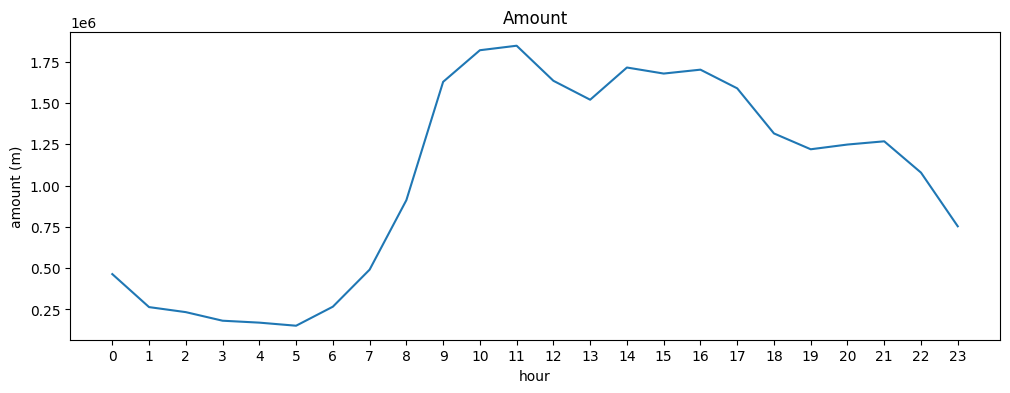

In [8]:
import matplotlib.pyplot as plt

amount = df.groupby('hour')['Amount'].sum()
plt.figure(figsize=[12, 4])
plt.title('Amount')
plt.plot(amount)
plt.xticks(range(24))
plt.ylabel('amount (m)')
plt.xlabel('hour')
plt.show()

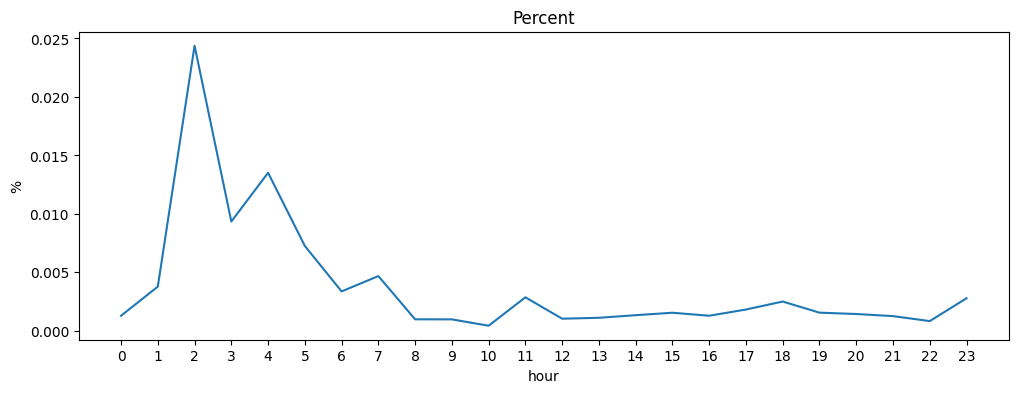

In [9]:
dist = df.groupby('hour')['Class'].sum().values / amount.values * 100
plt.figure(figsize=[12, 4])
plt.title('Percent')
plt.plot(dist)
plt.xticks(range(24))
plt.xlabel('hour')
plt.ylabel('%')
plt.show()

Text(0, 0.5, 'amount (1e7)')

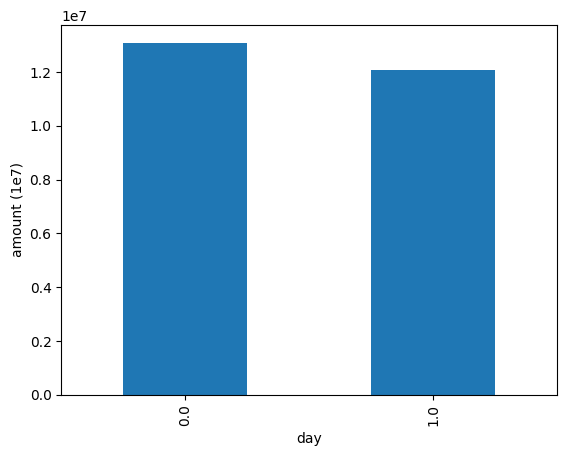

In [10]:
amount = df.groupby('day')['Amount'].sum()
amount.plot(kind='bar')
plt.ylabel('amount (1e7)')

In [11]:
amount

day
0.0    13093975.05
1.0    12068614.96
Name: Amount, dtype: float64

Text(0, 0.5, '%')

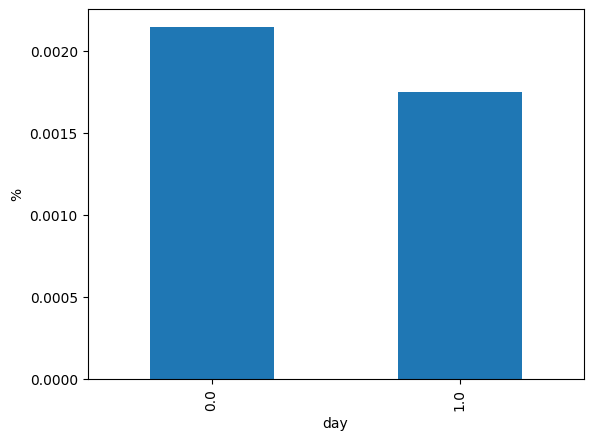

In [12]:
(df.groupby('day')['Class'].sum() / amount * 100).plot(kind='bar')
plt.ylabel('%')

In [13]:
l = len(df)
last20 = int(l * 0.2)
t = df[-last20:]
train = df[:-last20]
len(t)

56961

In [14]:
len(train) + len(t) == len(df)

True

In [15]:
val_size = int(last20 / 2)
test, val = t[:val_size], t[val_size:]
len(test) + len(val), len(t)

(56961, 56961)

# Часть 1. Supervised для сравнения

## Metrics

In [16]:
from sklearn.metrics import precision_score as precision, recall_score as recall, auc, precision_recall_curve

def auc_pr(y_true, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

from sklearn.metrics import accuracy_score as accuracy

def kappa(y_true, y_pred):
    p_o = accuracy(y_true, y_pred)
    a = y_true.mean() * y_pred.mean()
    b = (1 - y_true.mean()) * (1 - y_pred.mean())
    p_e = a + b
    return (p_o - p_e) / (1 - p_e)

import numpy as np
def MCC(y_true, y_pred) -> float:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    d = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    if d == 0.0:
        return 0.0
    
    return float(tp * tn - fp * fn) / np.sqrt(d)

In [17]:
X_train, y_train = train.drop(columns='Class'), train['Class']
X_test, y_test = test.drop(columns='Class'), test['Class']
X_val, y_val = val.drop(columns='Class'), val['Class']

## Catboost

Обучим обычный катбуст в качестве бейзлайна и посмотрим как он справился

In [18]:
from catboost import CatBoostClassifier

classifier = CatBoostClassifier(
    iterations=1000,
    depth=3,
    loss_function='CrossEntropy',
    eval_metric='AUC',
    random_seed=12
)

classifier = classifier.fit(
    X_train, 
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

y_probs = classifier.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_pred):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

0:	test: 0.8954876	best: 0.8954876 (0)	total: 59.6ms	remaining: 59.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9563327147
bestIteration = 34

Shrink model to first 35 iterations.
AUC-PR:  0.7740  
Kappa:   0.7069  
MCC:     0.7394  


Одно из решений для несбалансированной классификации - катбуст с увеличинным весом функции потерь для минорного класса

In [19]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'ratio: {ratio:0.2f}')

classifier_scaled = CatBoostClassifier(
    iterations=1000,
    depth=3,
    scale_pos_weight=ratio,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12
)

classifier_scaled = classifier_scaled.fit(
    X_train, 
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

y_probs_scaled = classifier_scaled.predict_proba(X_test)[:, 1]

y_pred_scaled = (y_probs_scaled > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs_scaled):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred_scaled):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred_scaled):<8.4f}')

ratio: 545.39
Learning rate set to 0.121129
0:	test: 0.8863285	best: 0.8863285 (0)	total: 12.3ms	remaining: 12.3s
100:	test: 0.9698274	best: 0.9870835 (51)	total: 1.2s	remaining: 10.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9870834917
bestIteration = 51

Shrink model to first 52 iterations.
AUC-PR:  0.8319  
Kappa:   0.2334  
MCC:     0.3481  


Подберем правильные гиперпараметры

In [20]:
weights = [1, 10, 50, 180, 545, 800]
best_weight = 1
best_auc_pr = -1

vals = []

for weight in weights:
    model = CatBoostClassifier(
        iterations=1000,
        depth=3,
        scale_pos_weight=weight,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12,
        verbose=0
    )
    model.fit(
        X_train, 
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    val = auc_pr(y_val, model.predict_proba(X_val)[:, 1])
    vals.append(val)

    if val > best_auc_pr:
        best_auc_pr = val
        best_weight = weight
print('(weight, auc-pr)')
print(*zip(weights, np.round(vals, 2)), sep='\n')
classifier_best = CatBoostClassifier(
    iterations=1000,
    depth=3,
    scale_pos_weight=best_weight,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12,
    verbose=0
)
classifier_best.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val), 
    early_stopping_rounds=50
)

y_probs_val = classifier_best.predict_proba(X_val)[:, 1]
_, _, thresholds = precision_recall_curve(y_val, y_probs_val)
best_threshold = 0.5
best_mcc = -1

for threshold in thresholds:
    y_pred_val = (y_probs_val >= threshold).astype(int)
    mcc_val = MCC(y_val, y_pred_val)
    if mcc_val > best_mcc:
        best_mcc = mcc_val
        best_threshold = threshold

y_probs = classifier_best.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= best_threshold).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

(weight, auc-pr)
(1, 0.56)
(10, 0.54)
(50, 0.66)
(180, 0.64)
(545, 0.67)
(800, 0.43)
AUC-PR:  0.8124  
Kappa:   0.7952  
MCC:     0.8124  


## SMOTE

Есть еще метод SMOTE, где мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами и добавляем в выборку. 

In [21]:
from imblearn.over_sampling import SMOTE

ratios = [0.1, 0.25, 0.5, 1.0]

for ratio in ratios:
    smote = SMOTE(sampling_strategy=ratio, random_state=12)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        depth=3,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12,
        verbose=0
    )

    model.fit(X_resampled, y_resampled, eval_set=(X_val, y_val), early_stopping_rounds=50)

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= best_threshold).astype(int)
    
    print(f'{"Ratio:":<8} {ratio:<8.4f}')
    print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs):<8.4f}')
    print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
    print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')
    print()

Ratio:   0.1000  
AUC-PR:  0.8315  
Kappa:   0.8219  
MCC:     0.8353  

Ratio:   0.2500  
AUC-PR:  0.8269  
Kappa:   0.8087  
MCC:     0.8239  

Ratio:   0.5000  
AUC-PR:  0.8089  
Kappa:   0.6578  
MCC:     0.7001  

Ratio:   1.0000  
AUC-PR:  0.6395  
Kappa:   0.0000  
MCC:     0.0000  



# Часть 2. Unsupervised

## LOF

In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor


n_neighbors = [5, 10, 20]
leaf_sizes = [30, 50]
contamination = 0.01
thresholds = [0.01, 0.05, 0.1, 0.3]

res = pd.DataFrame(columns=['N Neighbours', 'Leaf size', 'Threshold', 'AUC_PR', 'AUC-ROC', 'Kappa', 'MCC'])
i = 0

for n_neigh in n_neighbors:
    for leaf_size in leaf_sizes:
        print(f'{"Neighbours:":<12} {n_neigh:<12}')
        print(f'{"Leaf size:":<12} {leaf_size:<12}')

        model = LocalOutlierFactor(
            algorithm='kd_tree',
            n_neighbors=n_neigh, 
            contamination=contamination,
            metric='euclidean', 
            p=2,
            leaf_size=leaf_size,       
            novelty=True,
            n_jobs=-1     
        )

        model.fit(X_train)
        scores = model.score_samples(X_test)
        
        best_threshold = 0
        best_mcc = -1

        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}')
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()

        res.loc[i] = [n_neigh,
                      leaf_size,
                      best_threshold, 
                      auc_pr(y_test, y_pred),
                      roc_auc_score(y_test, y_pred), 
                      kappa(y_test, y_pred),
                      MCC(y_test, y_pred)
                    ]
        i += 1


Neighbours:  5           
Leaf size:   30          


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

Neighbours:  5           
Leaf size:   50          


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

Neighbours:  10          
Leaf size:   30          


...

Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

Neighbours:  20          
Leaf size:   30          


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

Neighbours:  20          
Leaf size:   50          


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      



In [23]:
res

,N Neighbours,Leaf size,Threshold,AUC_PR,AUC-ROC,Kappa,MCC
0,5.0,30.0,0.01,0.50093,0.5,0.0,0.0
1,5.0,50.0,0.01,0.50093,0.5,0.0,0.0
2,10.0,30.0,0.01,0.50093,0.5,0.0,0.0
3,10.0,50.0,0.01,0.50093,0.5,0.0,0.0
4,20.0,30.0,0.01,0.50093,0.5,0.0,0.0
5,20.0,50.0,0.01,0.50093,0.5,0.0,0.0


## One class SVM

In [25]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score

kernels = ['linear', 'rbf', 'poly']
nu = 0.2 # for speed
gammas = ['scale', 'auto']
thresholds = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]

res = pd.DataFrame(columns=['Kernel','Gamma', 'Threshold', 'AUC_PR', 'AUC-ROC', 'Kappa', 'MCC'])
i = 0

for kernel in kernels:
    for gamma in gammas:
        print(f'{"Kernel:":<12} {kernel:<12}')
        print(f'{"Gamma:":<12} {gamma:<12}')

        model = OneClassSVM(
            kernel=kernel,
            nu=nu,
            gamma=gamma,
            shrinking=True, # for speed
            max_iter=1000,
            tol=1e-4,
        )
        model.fit(X_train)
        scores = model.decision_function(X_test)
        
        scores = (scores - scores.min()) / (scores.max() - scores.min())
        
        best_threshold = 0
        best_mcc = -1

        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}') 
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()

        res.loc[i] = [kernel,
                        gamma,
                        best_threshold, 
                        auc_pr(y_test, y_pred),
                        roc_auc_score(y_test, y_pred), 
                        kappa(y_test, y_pred),
                        MCC(y_test, y_pred)]
        i += 1

Kernel:      linear      
Gamma:       scale       
Threshold:   0.2000      
AUC-PR:      0.4445      
AUC-ROC:     0.5488      
Kappa:       0.0005      
MCC:         0.0103      

Kernel:      linear      
Gamma:       auto        
Threshold:   0.2000      
AUC-PR:      0.4445      
AUC-ROC:     0.5488      
Kappa:       0.0005      
MCC:         0.0103      

Kernel:      rbf         
Gamma:       scale       


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5056      
Kappa:       0.0000      
MCC:         0.0046      

Kernel:      rbf         
Gamma:       auto        


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.3000      
AUC-PR:      0.0009      
AUC-ROC:     0.5000      
Kappa:       -0.0001     
MCC:         -0.0003     

Kernel:      poly        
Gamma:       scale       
Threshold:   0.2000      
AUC-PR:      0.4446      
AUC-ROC:     0.5559      
Kappa:       0.0005      
MCC:         0.0115      

Kernel:      poly        
Gamma:       auto        
Threshold:   0.2000      
AUC-PR:      0.4446      
AUC-ROC:     0.5559      
Kappa:       0.0005      
MCC:         0.0115      



In [26]:
res

,Kernel,Gamma,Threshold,AUC_PR,AUC-ROC,Kappa,MCC
0,linear,scale,0.20,0.444547,0.548754,0.000459,0.010308
1,linear,auto,0.20,0.444547,0.548754,0.000459,0.010308
2,rbf,scale,0.01,0.500941,0.505646,0.000043,0.004610
3,rbf,auto,0.30,0.000930,0.499982,-0.000069,-0.000256
4,poly,scale,0.20,0.444566,0.555930,0.000537,0.011548
5,poly,auto,0.20,0.444566,0.555930,0.000537,0.011548


## Isolation Forest

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_estimators_list = [50, 100, 200]
subsample_rates = [0.1, 0.2, 0.5]
contamination = 0.01 

for n_estimators in n_estimators_list:
    for subsample in subsample_rates:
        print(f'{"N Estimators:":<12} {n_estimators:<12.4f}')
        print(f'{"AUC-PR:":<12} {subsample:<12.4f}')

        model = IsolationForest(
            n_estimators=n_estimators,
            max_samples=subsample,
            contamination=contamination
        )

        model.fit(X_train_scaled)
        scores = model.score_samples(X_test_scaled)
        
        best_threshold = 0
        best_mcc = -1
        thresholds = np.linspace(np.min(scores), np.max(scores), 10)
        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}')
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()


N Estimators: 50.0000     
AUC-PR:      0.1000      
Threshold:   -0.6215     
AUC-PR:      0.5009      
AUC-ROC:     0.5006      
Kappa:       0.0000      
MCC:         0.0014      

N Estimators: 50.0000     
AUC-PR:      0.2000      
Threshold:   -0.6072     
AUC-PR:      0.5009      
AUC-ROC:     0.5007      
Kappa:       0.0000      
MCC:         0.0016      

N Estimators: 50.0000     
AUC-PR:      0.5000      
Threshold:   -0.6038     
AUC-PR:      0.5009      
AUC-ROC:     0.5004      
Kappa:       0.0000      
MCC:         0.0013      

N Estimators: 100.0000    
AUC-PR:      0.1000      
Threshold:   -0.6177     
AUC-PR:      0.5009      
AUC-ROC:     0.5006      
Kappa:       0.0000      
MCC:         0.0015      

N Estimators: 100.0000    
AUC-PR:      0.2000      
Threshold:   -0.6247     
AUC-PR:      0.5009      
AUC-ROC:     0.5005      
Kappa:       0.0000      
MCC:         0.0014      

N Estimators: 100.0000    
AUC-PR:      0.5000      
Threshold:   -0.6061     
A

# Итоги

Все табличные методы на таких данных у меня не показали никакого результата. Скорее всего я как-то непарвильно подобрал гиперпараметры, но `LOF` c `brute` вместо `kd_tree` обучается часами. SVM обучается тоже по пол часа с $\nu=0.2$, а если брать дефолтное 0.5 то с моими гиперпараметрами он тоже застревает на первой итерации. Все мои выборки из гипермпараметров не дали никакого результата. В моей прошлой работе у меня тоже не получилось добиться значимого качества.